<a href="https://colab.research.google.com/github/hmcnulty/Bayesian-Stats/blob/main/module04_bernoulli_hands_on_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Summarizing a Bernoulli posterior (Python)

Run the supplied cells through **Compile and sample**, then complete the calculations in **Your turn**.
This notebook uses Colab's **Python** runtime with a **CPU**.
Choose the matching language under **Runtime → Change runtime type**.

## Setup

In [2]:
%pip install -q cmdstanpy==1.3.0

In [4]:
from pathlib import Path
import shutil
import urllib.request

In [5]:
import cmdstanpy
from cmdstanpy import CmdStanModel
import numpy as np
import matplotlib.pyplot as plt

In [6]:
CMDSTAN_VERSION = "2.39.0"
cmdstan_dir = Path(f"/content/cmdstan-{CMDSTAN_VERSION}")
archive_path = Path(f"/content/colab-cmdstan-{CMDSTAN_VERSION}.tgz")

In [7]:
archive_url = (
    f"https://github.com/stan-dev/cmdstan/releases/download/v{CMDSTAN_VERSION}/"
    f"colab-cmdstan-{CMDSTAN_VERSION}.tgz"
)

In [8]:
if not cmdstan_dir.exists():
    urllib.request.urlretrieve(archive_url, archive_path)
    shutil.unpack_archive(archive_path, "/content")

In [9]:
cmdstanpy.set_cmdstan_path(str(cmdstan_dir))
print(f"CmdStanPy {cmdstanpy.__version__}")
print(f"CmdStan {cmdstanpy.cmdstan_version()}")

CmdStanPy 1.3.0
CmdStan (2, 39)


## Data

Here is the list of observations we will use:

In [10]:
X = [0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]

We give Stan the individual outcomes in `X` and the number of observations, `N`.

In [11]:
bernoulli_data = {"N": len(X), "X": X}
bernoulli_data

{'N': 20, 'X': [0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0]}

## Bernoulli model

We model the observations as conditionally independent Bernoulli variables with a common probability $\rho$ of observing a 1:

$$
X_i\mid\rho\sim\operatorname{Bernoulli}(\rho),\qquad
\rho\sim\operatorname{Beta}(1.5,1.5).
$$

The `data` block expects `N` and `X`.
The unknown is `rho`, and it is written into the `parameters` block.
The statement `X ~ bernoulli(rho);` applies the Bernoulli likelihood to every entry of `X`.

In [12]:
stan_code = r"""
data {
  int<lower=1> N;
  array[N] int<lower=0, upper=1> X;
}
parameters {
  real<lower=0, upper=1> rho;
}
model {
  rho ~ beta(1.5, 1.5);
  X ~ bernoulli(rho);
}
"""

We save this model to `bernoulli.stan` in the current working directory.

In [13]:
stan_file = Path("bernoulli.stan")
stan_file.write_text(stan_code);

## Compile and sample

Next, we compile that file into a program:

In [14]:
model_bernoulli = CmdStanModel(stan_file=str(stan_file))

We ask for two chains (two sampling runs) and set a seed so we can reproduce the example.
We leave the other sampling settings at their defaults.
The result is a fit object containing draws from the posterior.

In [16]:
fit_bernoulli = model_bernoulli.sample(data=bernoulli_data, chains=2, seed=6300)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

## Your turn

Use the posterior draws in `fit_bernoulli` to complete the calculations below.
You can refer to Module 3 for extracting and plotting samples, and Module 4 for the summaries.

### 1. Plot the posterior

Extract the draws for `rho` into a vector called `rho_draws`.
Plot a histogram of these draws.

(2000,)


(array([  3.,  12.,  18.,  26.,  50.,  68.,  83., 100., 110., 154., 153.,
        171., 161., 143., 115., 135., 118., 100.,  67.,  60.,  52.,  37.,
         22.,  15.,   9.,   7.,   7.,   2.,   0.,   2.]),
 array([0.04608222, 0.06469024, 0.08329826, 0.10190628, 0.1205143 ,
        0.13912232, 0.15773034, 0.17633836, 0.19494637, 0.21355439,
        0.23216241, 0.25077043, 0.26937845, 0.28798647, 0.30659449,
        0.32520251, 0.34381053, 0.36241854, 0.38102656, 0.39963458,
        0.4182426 , 0.43685062, 0.45545864, 0.47406666, 0.49267468,
        0.5112827 , 0.52989071, 0.54849873, 0.56710675, 0.58571477,
        0.60432279]),
 <BarContainer object of 30 artists>)

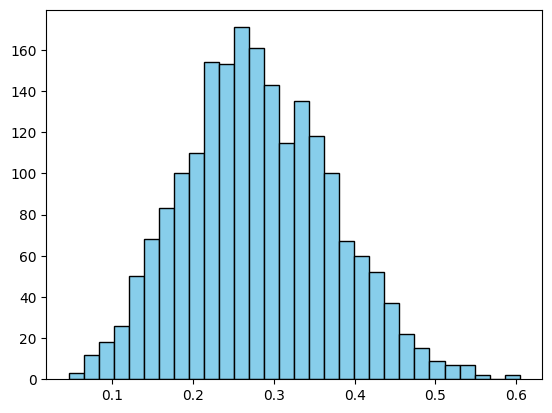

In [21]:
rho_draws = fit_bernoulli.stan_variable("rho")
### or -> rho_draws = fit_bernoulli.rho
print(rho_draws.shape)

plt.hist(rho_draws, bins=30, color='skyblue', edgecolor='black')

### 2. Point summaries

Calculate the posterior mean and median of $\rho$.

In [24]:
np.mean(rho_draws), np.median(rho_draws)

(np.float64(0.28070687036899994), np.float64(0.2750379))

### 3. A credible interval

Calculate the central 95% percentile interval for $\rho$.
Interpret this interval in one sentence.

In [ ]:
# Your code here.

*Write your interpretation here.*

### 4. A posterior probability

Estimate $P(\rho<0.3\mid X)$ using the posterior draws.

In [ ]:
# Your code here.